Fraud Detection in Government Schemes using Rule-Based and AI Methods


Dataset is synthetically generated for demonstration purposes

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [2]:
data = {
    "user_id": list(range(101, 121)),
    "income": [18000,72000,25000,40000,15000,90000,30000,27000,21000,65000,
               23000,80000,19000,35000,22000,50000,26000,70000,24000,60000],
    "scheme_amount": [14000,10000,20000,12000,16000,15000,18000,17000,15000,20000,
                      19000,12000,14000,13000,21000,15000,20000,18000,16000,22000],
    "num_claims": [7,1,9,2,8,1,6,7,6,2,10,1,7,3,9,2,8,1,7,2],
    "age": [22,45,30,35,21,50,28,26,24,40,29,48,23,33,27,38,31,42,25,36],
    "bank_account": [55511,67892,55511,34561,55511,88822,99931,55511,22219,33344,
                     55511,77761,55511,66672,55511,44455,55511,88893,55511,22210],
    "device_id": ["A1","B2","A1","C3","A1","D4","E5","A1","F6","G7",
                  "A1","H8","A1","I9","A1","J10","A1","K11","A1","L12"]
}

df = pd.DataFrame(data)
df.head()

,user_id,income,scheme_amount,num_claims,age,bank_account,device_id
0,101,18000,14000,7,22,55511,A1
1,102,72000,10000,1,45,67892,B2
2,103,25000,20000,9,30,55511,A1
3,104,40000,12000,2,35,34561,C3
4,105,15000,16000,8,21,55511,A1


In [3]:
df['high_claim_flag'] = df['num_claims'] > 5
df['income_mismatch'] = df['scheme_amount'] > df['income'] * 0.6
df['duplicate_account'] = df.duplicated(subset=['bank_account'], keep=False)
df['device_shared'] = df.duplicated(subset=['device_id'], keep=False)

df[['user_id','high_claim_flag','income_mismatch','duplicate_account','device_shared']]

,user_id,high_claim_flag,income_mismatch,duplicate_account,device_shared
0,101,True,True,True,True
1,102,False,False,False,False
2,103,True,True,True,True
3,104,False,False,False,False
4,105,True,True,True,True
5,106,False,False,False,False
6,107,True,False,False,False
7,108,True,True,True,True
8,109,True,True,False,False
9,110,False,False,False,False


In [5]:
df['risk_score'] = (
    df['high_claim_flag'].astype(int) * 30 +
    df['income_mismatch'].astype(int) * 25 +
    df['duplicate_account'].astype(int) * 25 +
    df['device_shared'].astype(int) * 20
)

df[['user_id','risk_score']]

,user_id,risk_score
0,101,100
1,102,0
2,103,100
3,104,0
4,105,100
5,106,0
6,107,30
7,108,100
8,109,55
9,110,0


In [6]:
df_numeric = df[['income', 'scheme_amount', 'num_claims', 'age']]

model = IsolationForest(contamination=0.3, random_state=42)
df['anomaly'] = model.fit_predict(df_numeric)
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})

df[['user_id','anomaly']]

,user_id,anomaly
0,101,0
1,102,1
2,103,0
3,104,0
4,105,0
5,106,1
6,107,0
7,108,0
8,109,0
9,110,0


In [7]:
df['fraud'] = ((df['risk_score'] > 40) | (df['anomaly'] == 1))

df[['user_id','risk_score','anomaly','fraud']]

,user_id,risk_score,anomaly,fraud
0,101,100,0,True
1,102,0,1,True
2,103,100,0,True
3,104,0,0,False
4,105,100,0,True
5,106,0,1,True
6,107,30,0,False
7,108,100,0,True
8,109,55,0,True
9,110,0,0,False


In [8]:
def label_risk(score):
    if score >= 60:
        return "High Risk"
    elif score >= 30:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_label'] = df['risk_score'].apply(label_risk)

df[['user_id','risk_score','risk_label']]

,user_id,risk_score,risk_label
0,101,100,High Risk
1,102,0,Low Risk
2,103,100,High Risk
3,104,0,Low Risk
4,105,100,High Risk
5,106,0,Low Risk
6,107,30,Medium Risk
7,108,100,High Risk
8,109,55,Medium Risk
9,110,0,Low Risk


In [9]:
def get_reason(row):
    reasons = []
    if row['high_claim_flag']:
        reasons.append("High claims")
    if row['income_mismatch']:
        reasons.append("Income mismatch")
    if row['duplicate_account']:
        reasons.append("Duplicate account")
    if row['device_shared']:
        reasons.append("Shared device")
    return ", ".join(reasons)

df['fraud_reason'] = df.apply(get_reason, axis=1)

df[['user_id','fraud_reason']]

,user_id,fraud_reason
0,101,"High claims, Income mismatch, Duplicate accoun..."
1,102,
2,103,"High claims, Income mismatch, Duplicate accoun..."
3,104,
4,105,"High claims, Income mismatch, Duplicate accoun..."
5,106,
6,107,High claims
7,108,"High claims, Income mismatch, Duplicate accoun..."
8,109,"High claims, Income mismatch"
9,110,


In [10]:
print("Total Users:", len(df))
print("Fraud Cases:", df['fraud'].sum())

df[df['fraud'] == True]

Total Users: 20
Fraud Cases: 15


,user_id,income,scheme_amount,num_claims,age,bank_account,device_id,high_claim_flag,income_mismatch,duplicate_account,device_shared,risk_score,anomaly,fraud,risk_label,fraud_reason
0,101,18000,14000,7,22,55511,A1,True,True,True,True,100,0,True,High Risk,"High claims, Income mismatch, Duplicate accoun..."
1,102,72000,10000,1,45,67892,B2,False,False,False,False,0,1,True,Low Risk,
2,103,25000,20000,9,30,55511,A1,True,True,True,True,100,0,True,High Risk,"High claims, Income mismatch, Duplicate accoun..."
4,105,15000,16000,8,21,55511,A1,True,True,True,True,100,0,True,High Risk,"High claims, Income mismatch, Duplicate accoun..."
5,106,90000,15000,1,50,88822,D4,False,False,False,False,0,1,True,Low Risk,
7,108,27000,17000,7,26,55511,A1,True,True,True,True,100,0,True,High Risk,"High claims, Income mismatch, Duplicate accoun..."
8,109,21000,15000,6,24,22219,F6,True,True,False,False,55,0,True,Medium Risk,"High claims, Income mismatch"
10,111,23000,19000,10,29,55511,A1,True,True,True,True,100,0,True,High Risk,"High claims, Income mismatch, Duplicate accoun..."
11,112,80000,12000,1,48,77761,H8,False,False,False,False,0,1,True,Low Risk,
12,113,19000,14000,7,23,55511,A1,True,True,True,True,100,0,True,High Risk,"High claims, Income mismatch, Duplicate accoun..."


In [12]:
print(df[['user_id','risk_label']].value_counts())

user_id  risk_label 
101      High Risk      1
102      Low Risk       1
103      High Risk      1
104      Low Risk       1
105      High Risk      1
106      Low Risk       1
107      Medium Risk    1
108      High Risk      1
109      Medium Risk    1
110      Low Risk       1
111      High Risk      1
112      Low Risk       1
113      High Risk      1
114      Low Risk       1
115      High Risk      1
116      Low Risk       1
117      High Risk      1
118      Low Risk       1
119      High Risk      1
120      Low Risk       1
Name: count, dtype: int64


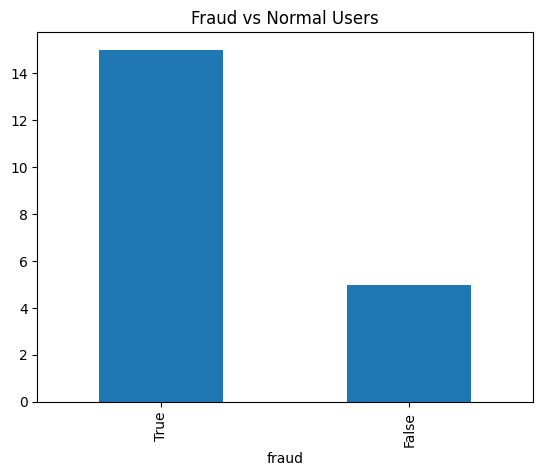

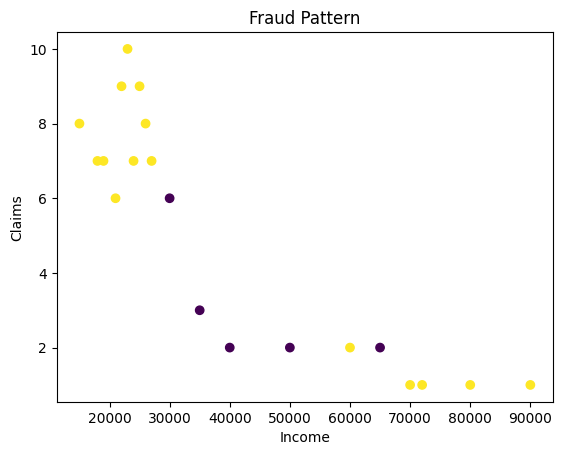

In [13]:
df['fraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Normal Users")
plt.show()

plt.scatter(df['income'], df['num_claims'], c=df['fraud'])
plt.xlabel("Income")
plt.ylabel("Claims")
plt.title("Fraud Pattern")
plt.show()